# 00 - Dataset and Partitioning

This vignette executes repository code to inspect the CIC-IDS2017 data pipeline.

The dataset is **network-flow telemetry**, not medical or clinical data. The hospital
naming convention represents healthcare organizations operating local networks. It does
not represent patient records, diagnoses, imaging, lab results, prescriptions, or clinical
decision support.

Binary labels mean:

- `0`: benign network flow
- `1`: malicious / attack network flow

In [1]:
from pathlib import Path
import os

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
ROOT

PosixPath('/Users/david/Documents/GitHub/project')

## 1. Source files and processed metadata

The download step is intentionally not executed from the notebook because it requires
Kaggle credentials and a large external download. The code below still executes against
the local repository and reports whether the raw and processed artifacts are present.

In [2]:
import json
from pathlib import Path
import pandas as pd

raw_csvs = sorted(Path("data/raw").glob("*.csv"))
processed_meta = Path("data/processed/cicids_clean.metadata.json")

print(f"raw CSV files: {len(raw_csvs)}")
print("first raw files:", [path.name for path in raw_csvs[:4]])
print(f"processed metadata exists: {processed_meta.exists()}")

if processed_meta.exists():
    meta = json.loads(processed_meta.read_text())
    print(f"processed rows: {meta['rows']:,}")
    print(f"numeric features: {meta['num_features']}")
    attack_distribution = (
        pd.Series(meta["attack_distribution"], name="rows")
        .sort_values(ascending=False)
        .rename_axis("original_label")
        .reset_index()
    )
    attack_distribution.head(12)

raw CSV files: 8
first raw files: ['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv']
processed metadata exists: True
processed rows: 2,830,743
numeric features: 78


## 2. Non-IID healthcare-network partitions

`scripts/make_partitions.py` creates six simulated healthcare-network sites with seed
`123`. The site names remain `hospital_*` because the demo is about hospital network
operators, but the rows are still CIC-IDS2017 network-flow records.

In [3]:
rows = []
for meta_path in sorted(Path("data/partitions").glob("*/metadata.json")):
    item = json.loads(meta_path.read_text())
    rows.append({
        "site_id": item["hospital_id"],
        "region": item["region"],
        "num_train": item["num_train"],
        "num_val": item["num_val"],
        "num_test": item["num_test"],
        "num_features": item["num_features"],
        "train_benign": item["train_label_counts"].get("0", 0),
        "train_attack": item["train_label_counts"].get("1", 0),
    })

partition_df = pd.DataFrame(rows)
partition_df

,site_id,region,num_train,num_val,num_test,num_features,train_benign,train_attack
0,hospital_eu_01,region_eu,4710,1009,1010,78,3710,1000
1,hospital_eu_02,region_eu,30994,6642,6642,78,1732,29262
2,hospital_eu_03,region_eu,835469,179029,179030,78,825001,10468
3,hospital_na_01,region_na,510580,109410,109410,78,343902,166678
4,hospital_na_02,region_na,91259,19556,19556,78,63012,28247
5,hospital_na_03,region_na,508505,108966,108966,78,353809,154696


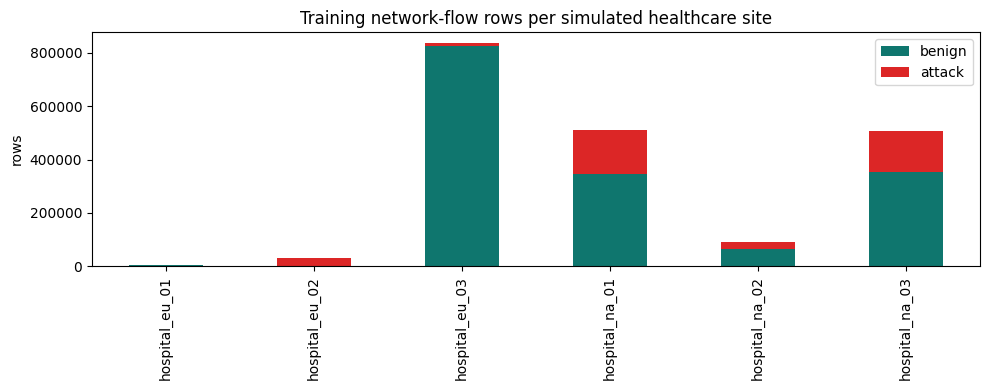

In [4]:
import matplotlib.pyplot as plt

if partition_df.empty:
    print("No partition metadata found. Run: make partition SEED=123")
else:
    ax = (
        partition_df
        .set_index("site_id")[["train_benign", "train_attack"]]
        .plot(kind="bar", stacked=True, figsize=(10, 4), color=["#0f766e", "#dc2626"])
    )
    ax.set_title("Training network-flow rows per simulated healthcare site")
    ax.set_ylabel("rows")
    ax.set_xlabel("")
    ax.legend(["benign", "attack"], loc="upper right")
    plt.tight_layout()

## 3. Raw-data boundary check

After partitioning, `shared/` may contain checkpoints, metrics, and preprocessing
metadata. It should not contain raw CSV or parquet network-flow rows.

In [5]:
shared_data_files = sorted(
    list(Path("shared").rglob("*.csv"))
    + list(Path("shared").rglob("*.parquet"))
)
[str(path) for path in shared_data_files]

[]